# Imports

In [1]:
import math
import time
import random
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Setup & Device

In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

Using device: cuda


# Configuration

In [ ]:
@dataclass
class Config:
    # task
    sequence_length: int = 4096
    num_tokens_memorize: int = 16
    vocab_size: int = 16  # matches repo

    # model
    d_model: int = 64
    expand_dim: int = 6
    num_layers: int = 3
    dropout: float = 0.1
    ff_mult: int = 2
    enable_ff: bool = False
    kernel_size: int = 0
    norm_type: str = "RMSNorm"
    use_coeff_norm: bool = False
    use_init_hidden_state: bool = True
    forget_bias_init_scale: float = 3.0

    # optimization
    lr: float = 3e-4
    weight_decay: float = 0.05
    clip: float = 1.0

    # training
    train_batch_size: int = 64
    eval_batch_size: int = 64
    accum_iter: int = 2
    num_steps: int = 400000
    print_freq: int = 100
    eval_freq: int = 1000

    # notebook practicality
    scan_cpu_fallback_on_mps: bool = True

CFG = Config()

FAST_DEV_RUN = False

if FAST_DEV_RUN:
    CFG.sequence_length = 128
    CFG.num_tokens_memorize = 8
    CFG.train_batch_size = 64
    CFG.eval_batch_size = 64
    CFG.num_steps = 5000
    CFG.num_layers = 2
    CFG.d_model = 64
    CFG.expand_dim = 4
    CFG.lr = 1e-3
else: # change accordingly for a longer run
    CFG.sequence_length = 256
    CFG.train_batch_size = 64
    CFG.eval_batch_size = 64
    CFG.accum_iter = 1
    CFG.num_steps = 5000      
    CFG.eval_freq = 250
    CFG.print_freq = 100
    CFG.lr = 1e-3
    CFG.num_layers = 2
    CFG.d_model = 64
    CFG.expand_dim = 4
    CFG.num_tokens_memorize = 8

print(CFG)

Config(sequence_length=256, num_tokens_memorize=8, vocab_size=16, d_model=64, expand_dim=4, num_layers=2, dropout=0.1, ff_mult=2, enable_ff=False, kernel_size=0, norm_type='RMSNorm', use_coeff_norm=False, use_init_hidden_state=True, forget_bias_init_scale=3.0, lr=0.001, weight_decay=0.05, clip=1.0, train_batch_size=64, eval_batch_size=64, accum_iter=1, num_steps=5000, print_freq=100, eval_freq=250, scan_cpu_fallback_on_mps=True)


# Helpers from the minRNN repo

In [4]:
def exists(x):
    return x is not None

def g(x):
    # from official repo
    return torch.where(x >= 0, x + 0.5, x.sigmoid())

def log_g(x):
    # from official repo
    return torch.where(x >= 0, (F.relu(x) + 0.5).log(), -F.softplus(-x))

def associative_scan_log(log_coeffs, log_values, return_log=False):
    """
    Official repo uses:
        a_star = log_coeffs.cumsum(dim=1)
        log_h0_plus_b_star = (log_values - a_star).logcumsumexp(dim=1)
        log_h = a_star + log_h0_plus_b_star
    """
    a_star = log_coeffs.cumsum(dim=1)
    log_h0_plus_b_star = (log_values - a_star).logcumsumexp(dim=1)
    log_h = a_star + log_h0_plus_b_star
    return log_h if return_log else log_h.exp()

# Normalization, Feedforward and Conv blocks

In [5]:
class RMSNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.scale = dim ** 0.5
        self.gamma = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        return F.normalize(x, dim=-1) * self.scale * (self.gamma + 1.0)

class BatchNorm(nn.Module):
    def __init__(self, dim, momentum=0.9):
        super().__init__()
        self.norm = nn.BatchNorm1d(dim, momentum=momentum)

    def forward(self, x):
        # x: [B, L, D]
        return self.norm(x.permute(0, 2, 1)).permute(0, 2, 1)

class GEGLU(nn.Module):
    def __init__(self, dim, mult_bias=True):
        super().__init__()
        self.mult_bias = nn.Parameter(torch.ones(dim)) if mult_bias else 1.0

    def forward(self, x):
        x, gate = x.chunk(2, dim=-1)
        return F.gelu(gate) * x * self.mult_bias

def FeedForward(dim, mult=4, dropout=0.1):
    dim_inner = int(dim * mult)
    return nn.Sequential(
        nn.Linear(dim, dim_inner * 2),
        GEGLU(dim_inner),
        nn.Linear(dim_inner, dim),
        nn.Dropout(dropout),
    )

class CausalDepthWiseConv1d(nn.Module):
    def __init__(self, dim, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.net = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=kernel_size, groups=dim),
            nn.Conv1d(dim, dim, kernel_size=1),
        )

    def forward(self, x):
        # x: [B, L, D]
        x = x.transpose(1, 2)               # [B, D, L]
        x = F.pad(x, (self.kernel_size - 1, 0), value=0.0)
        x = self.net(x)
        return x.transpose(1, 2)            # [B, L, D]

# minGRU & minLSTM implementation

In [6]:
class minGRU(nn.Module):
    def __init__(self, dim, expansion_factor=6, use_init_hidden_state=True,
                 scan_cpu_fallback_on_mps=True, **kwargs):
        super().__init__()
        dim_inner = int(dim * expansion_factor)
        self.to_hidden_and_gate = nn.Linear(dim, dim_inner * 2)
        self.to_out = nn.Linear(dim_inner, dim)
        self.init_hidden_state = (
            nn.Parameter(torch.randn(dim_inner), requires_grad=True)
            if use_init_hidden_state else None
        )
        self.scan_cpu_fallback_on_mps = scan_cpu_fallback_on_mps

    def _scan(self, log_coeffs, log_values):
        # optional CPU fallback for MPS numerical stability
        if (
            log_coeffs.device.type == "mps"
            and self.scan_cpu_fallback_on_mps
        ):
            lc_cpu = log_coeffs.cpu()
            lv_cpu = log_values.cpu()
            out_cpu = associative_scan_log(lc_cpu, lv_cpu, return_log=True)
            return out_cpu.to(log_coeffs.device)
        return associative_scan_log(log_coeffs, log_values, return_log=True)

    def forward(self, x, prev_state=None):
        seq_len = x.shape[1]
        hidden, gate = self.to_hidden_and_gate(x).chunk(2, dim=-1)

        if seq_len == 1:
            tilde_h = g(hidden)
            gate = gate.sigmoid()

            if exists(prev_state):
                prev_hidden, _ = prev_state
                out = (1 - gate) * prev_hidden + gate * tilde_h
            elif exists(self.init_hidden_state):
                prev_hidden = g(self.init_hidden_state)
                out = (1 - gate) * prev_hidden + gate * tilde_h
            else:
                out = gate * tilde_h

            next_hidden = out[:, -1:]
            next_log_hidden = out[:, -1:].clamp_min(1e-12).log()

        else:
            log_coeffs = -F.softplus(gate)
            log_z = -F.softplus(-gate)
            log_tilde_h = log_g(hidden)
            log_values = log_z + log_tilde_h

            if exists(prev_state) or exists(self.init_hidden_state):
                if exists(prev_state):
                    _, prev_log_hidden = prev_state
                else:
                    prev_log_hidden = log_g(self.init_hidden_state)
                    prev_log_hidden = prev_log_hidden.unsqueeze(0).unsqueeze(0)
                    prev_log_hidden = prev_log_hidden.repeat(log_values.shape[0], 1, 1)

                log_values = torch.cat((prev_log_hidden, log_values), dim=1)
                log_coeffs = F.pad(log_coeffs, (0, 0, 1, 0))

            log_out = self._scan(log_coeffs, log_values)
            out = torch.exp(log_out[:, -seq_len:])

            next_hidden = out[:, -1:]
            next_log_hidden = log_out[:, -1:]

        out = self.to_out(out)
        return out, (next_hidden, next_log_hidden)


class minLSTM(nn.Module):
    def __init__(self, dim, expansion_factor=6, forget_bias_init_scale=3.0,
                 use_coeff_norm=False, use_init_hidden_state=True,
                 scan_cpu_fallback_on_mps=True, **kwargs):
        super().__init__()
        dim_inner = int(dim * expansion_factor)
        self.to_hidden_and_gate = nn.Linear(dim, dim_inner * 3)
        self.to_out = nn.Linear(dim_inner, dim)
        self.use_coeff_norm = use_coeff_norm
        self.scan_cpu_fallback_on_mps = scan_cpu_fallback_on_mps

        if exists(forget_bias_init_scale):
            with torch.no_grad():
                to_add = torch.zeros_like(self.to_hidden_and_gate.bias)
                to_add[dim_inner:2 * dim_inner] = forget_bias_init_scale
                self.to_hidden_and_gate.bias += to_add

        self.init_hidden_state = (
            nn.Parameter(torch.randn(dim_inner), requires_grad=True)
            if use_init_hidden_state else None
        )

    def _scan(self, log_coeffs, log_values):
        if (
            log_coeffs.device.type == "mps"
            and self.scan_cpu_fallback_on_mps
        ):
            lc_cpu = log_coeffs.cpu()
            lv_cpu = log_values.cpu()
            out_cpu = associative_scan_log(lc_cpu, lv_cpu, return_log=True)
            return out_cpu.to(log_coeffs.device)
        return associative_scan_log(log_coeffs, log_values, return_log=True)

    def forward(self, x, prev_state=None):
        seq_len = x.shape[1]
        hidden, forget_gate, input_gate = self.to_hidden_and_gate(x).chunk(3, dim=-1)

        if seq_len == 1:
            tilde_h = g(hidden)
            input_gate = input_gate.sigmoid()
            forget_gate = forget_gate.sigmoid()

            if self.use_coeff_norm:
                norm = forget_gate + input_gate + 1e-12
                forget_gate = forget_gate / norm
                input_gate = input_gate / norm

            if exists(prev_state):
                prev_hidden, _ = prev_state
                out = forget_gate * prev_hidden + input_gate * tilde_h
            elif exists(self.init_hidden_state):
                prev_hidden = g(self.init_hidden_state)
                out = forget_gate * prev_hidden + input_gate * tilde_h
            else:
                out = input_gate * tilde_h

            next_hidden = out[:, -1:]
            next_log_hidden = out[:, -1:].clamp_min(1e-12).log()

        else:
            if self.use_coeff_norm:
                diff = F.softplus(-forget_gate) - F.softplus(-input_gate)
                log_coeffs = -F.softplus(diff)
                log_val_coeffs = -F.softplus(-diff)
            else:
                log_coeffs = -F.softplus(-forget_gate)
                log_val_coeffs = -F.softplus(-input_gate)

            log_tilde_h = log_g(hidden)
            log_values = log_val_coeffs + log_tilde_h

            if exists(prev_state) or exists(self.init_hidden_state):
                if exists(prev_state):
                    _, prev_log_hidden = prev_state
                else:
                    prev_log_hidden = log_g(self.init_hidden_state)
                    prev_log_hidden = prev_log_hidden.unsqueeze(0).unsqueeze(0)
                    prev_log_hidden = prev_log_hidden.repeat(log_values.shape[0], 1, 1)

                log_values = torch.cat((prev_log_hidden, log_values), dim=1)
                log_coeffs = F.pad(log_coeffs, (0, 0, 1, 0))

            log_out = self._scan(log_coeffs, log_values)
            out = torch.exp(log_out[:, -seq_len:])

            next_hidden = out[:, -1:]
            next_log_hidden = log_out[:, -1:]

        out = self.to_out(out)
        return out, (next_hidden, next_log_hidden)

# Sequential GRU & LSTM baselines

In [7]:
class SequentialGRUBlock(nn.Module):
    def __init__(self, dim, expansion_factor=6, **kwargs):
        super().__init__()
        hidden_size = int(dim * expansion_factor)
        self.rnn = nn.GRU(input_size=dim, hidden_size=hidden_size, batch_first=True)
        self.proj = nn.Linear(hidden_size, dim)

    def forward(self, x, prev_state=None):
        if prev_state is not None:
            h0 = prev_state[0].transpose(0, 1)  # [1, B, H]
        else:
            h0 = None
        out, h_n = self.rnn(x, h0)
        out = self.proj(out)
        next_hidden = h_n.transpose(0, 1)      # [B, 1, H]
        next_log_hidden = torch.log(next_hidden.abs().clamp_min(1e-12))
        return out, (next_hidden, next_log_hidden)

class SequentialLSTMBlock(nn.Module):
    def __init__(self, dim, expansion_factor=6, **kwargs):
        super().__init__()
        hidden_size = int(dim * expansion_factor)
        self.rnn = nn.LSTM(input_size=dim, hidden_size=hidden_size, batch_first=True)
        self.proj = nn.Linear(hidden_size, dim)

    def forward(self, x, prev_state=None):
        if prev_state is not None:
            h0 = prev_state[0].transpose(0, 1)
            c0 = prev_state[0].transpose(0, 1)
            state = (h0, c0)
        else:
            state = None
        out, (h_n, c_n) = self.rnn(x, state)
        out = self.proj(out)
        next_hidden = h_n.transpose(0, 1)
        next_log_hidden = torch.log(next_hidden.abs().clamp_min(1e-12))
        return out, (next_hidden, next_log_hidden)

# Full model wrapper

In [8]:
class ReplicationModel(nn.Module):
    def __init__(self, module_name: str, cfg: Config):
        super().__init__()
        self.module_name = module_name

        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)

        norm_cls = RMSNorm if cfg.norm_type == "RMSNorm" else BatchNorm

        block_map = {
            "minGRU": lambda: minGRU(
                dim=cfg.d_model,
                expansion_factor=cfg.expand_dim,
                use_init_hidden_state=cfg.use_init_hidden_state,
                scan_cpu_fallback_on_mps=cfg.scan_cpu_fallback_on_mps,
            ),
            "minLSTM": lambda: minLSTM(
                dim=cfg.d_model,
                expansion_factor=cfg.expand_dim,
                forget_bias_init_scale=cfg.forget_bias_init_scale,
                use_coeff_norm=cfg.use_coeff_norm,
                use_init_hidden_state=cfg.use_init_hidden_state,
                scan_cpu_fallback_on_mps=cfg.scan_cpu_fallback_on_mps,
            ),
            "GRU": lambda: SequentialGRUBlock(
                dim=cfg.d_model,
                expansion_factor=cfg.expand_dim,
            ),
            "LSTM": lambda: SequentialLSTMBlock(
                dim=cfg.d_model,
                expansion_factor=cfg.expand_dim,
            ),
        }

        self.layers = nn.ModuleList()
        for _ in range(cfg.num_layers):
            conv = CausalDepthWiseConv1d(cfg.d_model, cfg.kernel_size) if cfg.kernel_size not in [None, 0] else None
            self.layers.append(nn.ModuleList([
                conv,
                norm_cls(cfg.d_model),
                block_map[module_name](),
                norm_cls(cfg.d_model),
                FeedForward(cfg.d_model, mult=cfg.ff_mult, dropout=cfg.dropout) if cfg.enable_ff else None,
            ]))

        self.final_norm = norm_cls(cfg.d_model)
        self.to_out = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

    def forward(self, x, return_states=False, prev_states=None):
        x = self.token_emb(x)

        if prev_states is None:
            prev_states = [None for _ in range(len(self.layers))]

        next_prev_states = []
        for (conv, norm1, rnn_block, norm2, ff), prev_state in zip(self.layers, prev_states):
            if conv is not None:
                x = x + conv(x)

            out, next_state = rnn_block(norm1(x), prev_state=prev_state)
            x = x + out
            next_prev_states.append(next_state)

            if ff is not None:
                x = x + ff(norm2(x))

        logits = self.to_out(self.final_norm(x))
        return (logits, next_prev_states) if return_states else logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Selective Copy Task sampler

In [9]:
VOCAB_SIZE = CFG.vocab_size
EMPTY = VOCAB_SIZE - 1
PRED = 0

class SelectiveCopyTaskSampler:
    def __init__(self, sequence_length, num_tokens_memorize, seed=None):
        self.sequence_length = sequence_length
        self.num_tokens_memorize = num_tokens_memorize
        if seed is not None:
            set_seed(seed)

    def sample(self, batch_size=16, device="cpu"):
        # tokens to remember: values 1..VOCAB_SIZE-2
        tokens = torch.randint(
            low=1,
            high=VOCAB_SIZE - 1,
            size=(batch_size, self.num_tokens_memorize),
            device=device
        )

        inds = torch.stack([
            torch.randperm(self.sequence_length, device=device)[:self.num_tokens_memorize]
            for _ in range(batch_size)
        ], dim=0)
        inds, _ = inds.sort(dim=-1)

        sequence = EMPTY * torch.ones((batch_size, self.sequence_length), dtype=torch.long, device=device)
        sequence.scatter_(-1, inds, tokens)

        markers = PRED * torch.ones((batch_size, self.num_tokens_memorize), dtype=torch.long, device=device)

        x = torch.cat((sequence, markers), dim=1)  # [B, L + M]
        y = tokens                                  # [B, M]
        return {"x": x, "y": y}

# Loss function and metrics

In [10]:
def selective_copy_loss_and_acc(logits, batch, cfg: Config):
    # logits: [B, L+M, V]
    # only last M positions matter
    logits = logits[:, -cfg.num_tokens_memorize:]   # [B, M, V]
    target = batch["y"]                             # [B, M]

    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        target.reshape(-1)
    )
    acc = (logits.argmax(dim=-1) == target).float().mean()
    return loss, acc

# Train & Evaluation

In [11]:
@torch.no_grad()
def evaluate_model(model, cfg: Config, seed=0, num_batches=100, sequence_length=None):
    was_training = model.training
    model.eval()

    seq_len = sequence_length if sequence_length is not None else cfg.sequence_length
    sampler = SelectiveCopyTaskSampler(
        sequence_length=seq_len,
        num_tokens_memorize=cfg.num_tokens_memorize,
        seed=seed
    )

    losses = []
    accs = []

    for _ in range(num_batches):
        batch = sampler.sample(batch_size=cfg.eval_batch_size, device=DEVICE)
        logits = model(batch["x"])
        loss, acc = selective_copy_loss_and_acc(logits, batch, cfg)
        losses.append(loss.item())
        accs.append(acc.item())

    if was_training:
        model.train()

    return {
        "loss": float(np.mean(losses)),
        "acc": float(np.mean(accs)),
    }


def train_model(model_name: str, cfg: Config, seed=42, verbose=True):
    set_seed(seed)

    model = ReplicationModel(model_name, cfg).to(DEVICE)
    sampler = SelectiveCopyTaskSampler(
        sequence_length=cfg.sequence_length,
        num_tokens_memorize=cfg.num_tokens_memorize,
        seed=seed
    )

    params_with_decay = []
    params_without_decay = []

    for name, param in model.named_parameters():
        if "to_hidden_and_gate" in name:
            params_without_decay.append(param)
        else:
            params_with_decay.append(param)

    optimizer = torch.optim.AdamW(
        [
            {"params": params_with_decay, "weight_decay": cfg.weight_decay},
            {"params": params_without_decay, "weight_decay": 0.0},
        ],
        lr=cfg.lr,
    )

    history = {
        "step": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = None
    start = time.time()

    model.train()
    optimizer.zero_grad()

    running_loss = []
    running_acc = []

    for step in range(1, cfg.num_steps + 1):
        for _ in range(cfg.accum_iter):
            batch = sampler.sample(batch_size=cfg.train_batch_size // cfg.accum_iter, device=DEVICE)
            logits = model(batch["x"])
            loss, acc = selective_copy_loss_and_acc(logits, batch, cfg)
            (loss / cfg.accum_iter).backward()

            running_loss.append(loss.item())
            running_acc.append(acc.item())

        if cfg.clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip)

        optimizer.step()
        optimizer.zero_grad()

        if step % cfg.print_freq == 0:
            mean_train_loss = float(np.mean(running_loss[-cfg.print_freq:]))
            mean_train_acc = float(np.mean(running_acc[-cfg.print_freq:]))

            if verbose:
                print(
                    f"[{model_name}] step={step:6d} "
                    f"train_loss={mean_train_loss:.4f} "
                    f"train_acc={mean_train_acc:.4f}"
                )

        if step % cfg.eval_freq == 0 or step == cfg.num_steps:
            val_metrics = evaluate_model(model, cfg, seed=0, num_batches=50)

            model.train()

            history["step"].append(step)
            history["train_loss"].append(float(np.mean(running_loss[-cfg.eval_freq:])))
            history["train_acc"].append(float(np.mean(running_acc[-cfg.eval_freq:])))
            history["val_loss"].append(val_metrics["loss"])
            history["val_acc"].append(val_metrics["acc"])

            if verbose:
                print(
                    f"   -> val_loss={val_metrics['loss']:.4f} "
                    f"val_acc={val_metrics['acc']:.4f}"
                )

            if val_metrics["acc"] >= best_val_acc:
                best_val_acc = val_metrics["acc"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    total_time = time.time() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_model(model, cfg, seed=1, num_batches=100)

    result = {
        "model_name": model_name,
        "seed": seed,
        "params": count_parameters(model),
        "best_val_acc": best_val_acc,
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "train_time_sec": total_time,
        "history": history,
        "model": model,
    }

    return result

# Sanity check on one batch

In [12]:
set_seed(42)

sampler = SelectiveCopyTaskSampler(CFG.sequence_length, CFG.num_tokens_memorize, seed=42)
batch = sampler.sample(batch_size=2, device=DEVICE)

print("x shape:", batch["x"].shape)
print("y shape:", batch["y"].shape)
print("example x[0, :40]:", batch["x"][0, :40])
print("target y[0]:", batch["y"][0])

test_model = ReplicationModel("minGRU", CFG).to(DEVICE)
with torch.no_grad():
    logits = test_model(batch["x"])
print("logits shape:", logits.shape)

x shape: torch.Size([2, 264])
y shape: torch.Size([2, 8])
example x[0, :40]: tensor([15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,  2, 15, 15, 15, 15, 15,
        15, 15, 15, 15], device='cuda:0')
target y[0]: tensor([ 2,  6, 13,  7,  6, 10, 11, 11], device='cuda:0')
logits shape: torch.Size([2, 264, 16])


# Train 1 model

In [13]:
FAST_DEV_RUN = True
single_result = train_model("minGRU", CFG, seed=42, verbose=True)
print({
    "params": single_result["params"],
    "best_val_acc": single_result["best_val_acc"],
    "test_acc": single_result["test_acc"],
    "test_loss": single_result["test_loss"],
    "train_time_sec": single_result["train_time_sec"],
})

[minGRU] step=   100 train_loss=2.6550 train_acc=0.0705
[minGRU] step=   200 train_loss=2.6437 train_acc=0.0718
   -> val_loss=2.6424 val_acc=0.0704
[minGRU] step=   300 train_loss=2.6372 train_acc=0.0859
[minGRU] step=   400 train_loss=2.4566 train_acc=0.1666
[minGRU] step=   500 train_loss=2.1253 train_acc=0.2321
   -> val_loss=2.0199 val_acc=0.2617
[minGRU] step=   600 train_loss=1.9307 train_acc=0.2846
[minGRU] step=   700 train_loss=1.7015 train_acc=0.3431
   -> val_loss=1.5316 val_acc=0.3926
[minGRU] step=   800 train_loss=1.5301 train_acc=0.3926
[minGRU] step=   900 train_loss=1.3298 train_acc=0.4558
[minGRU] step=  1000 train_loss=1.1954 train_acc=0.5106
   -> val_loss=1.1272 val_acc=0.5408
[minGRU] step=  1100 train_loss=1.0784 train_acc=0.5585
[minGRU] step=  1200 train_loss=0.9820 train_acc=0.6019
   -> val_loss=0.8968 val_acc=0.6442
[minGRU] step=  1300 train_loss=0.9009 train_acc=0.6319
[minGRU] step=  1400 train_loss=0.8127 train_acc=0.6755
[minGRU] step=  1500 train_loss

# Plot training curve for 1 model

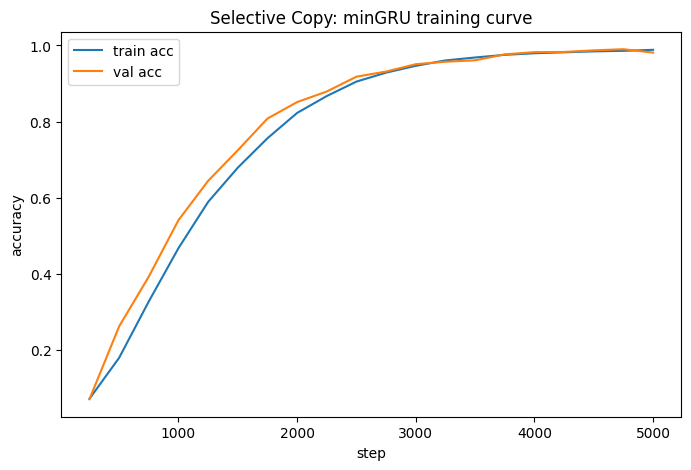

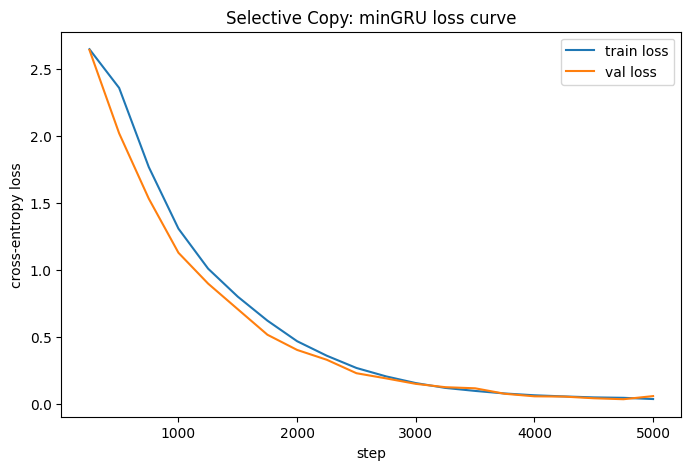

In [14]:
hist = pd.DataFrame(single_result["history"])

plt.figure(figsize=(8, 5))
plt.plot(hist["step"], hist["train_acc"], label="train acc")
plt.plot(hist["step"], hist["val_acc"], label="val acc")
plt.xlabel("step")
plt.ylabel("accuracy")
plt.title("Selective Copy: minGRU training curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["step"], hist["train_loss"], label="train loss")
plt.plot(hist["step"], hist["val_loss"], label="val loss")
plt.xlabel("step")
plt.ylabel("cross-entropy loss")
plt.title("Selective Copy: minGRU loss curve")
plt.legend()
plt.show()

# Compare across all models and seeds

In [15]:
MODELS = ["minGRU", "minLSTM", "GRU", "LSTM"]
SEEDS = [42, 43, 44]   # increase to 5 if have time

all_results = []

for model_name in MODELS:
    for seed in SEEDS:
        print(f"\n===== Training {model_name}, seed={seed} =====")
        result = train_model(model_name, CFG, seed=seed, verbose=True)
        all_results.append(result)


===== Training minGRU, seed=42 =====
[minGRU] step=   100 train_loss=2.6550 train_acc=0.0705
[minGRU] step=   200 train_loss=2.6437 train_acc=0.0718
   -> val_loss=2.6424 val_acc=0.0704
[minGRU] step=   300 train_loss=2.6372 train_acc=0.0859
[minGRU] step=   400 train_loss=2.4566 train_acc=0.1666
[minGRU] step=   500 train_loss=2.1253 train_acc=0.2321
   -> val_loss=2.0199 val_acc=0.2617
[minGRU] step=   600 train_loss=1.9307 train_acc=0.2846
[minGRU] step=   700 train_loss=1.7015 train_acc=0.3431
   -> val_loss=1.5316 val_acc=0.3926
[minGRU] step=   800 train_loss=1.5301 train_acc=0.3926
[minGRU] step=   900 train_loss=1.3298 train_acc=0.4558
[minGRU] step=  1000 train_loss=1.1954 train_acc=0.5106
   -> val_loss=1.1272 val_acc=0.5408
[minGRU] step=  1100 train_loss=1.0784 train_acc=0.5585
[minGRU] step=  1200 train_loss=0.9820 train_acc=0.6019
   -> val_loss=0.8968 val_acc=0.6442
[minGRU] step=  1300 train_loss=0.9009 train_acc=0.6319
[minGRU] step=  1400 train_loss=0.8127 train_acc=

# Aggregate results

In [16]:
rows = []
for r in all_results:
    rows.append({
        "model": r["model_name"],
        "seed": r["seed"],
        "params": r["params"],
        "best_val_acc": r["best_val_acc"],
        "test_acc": r["test_acc"],
        "test_loss": r["test_loss"],
        "train_time_sec": r["train_time_sec"],
    })

results_df = pd.DataFrame(rows)
results_df.sort_values(["model", "seed"])

,model,seed,params,best_val_acc,test_acc,test_loss,train_time_sec
6,GRU,42,529856,0.999961,0.999844,0.000663,93.214871
7,GRU,43,529856,1.000000,0.999883,0.000594,95.288023
8,GRU,44,529856,0.999961,0.999883,0.000812,97.832725
9,LSTM,42,694720,0.406484,0.399766,1.527961,97.833851
10,LSTM,43,694720,0.405000,0.402656,1.548761,98.358823
11,LSTM,44,694720,0.368125,0.370586,1.734639,97.984370
0,minGRU,42,102336,0.990078,0.988379,0.037143,75.828032
1,minGRU,43,102336,0.990898,0.990801,0.031117,75.608542
2,minGRU,44,102336,0.995352,0.995410,0.014651,75.422547
3,minLSTM,42,135616,0.801914,0.804629,0.495418,76.527905


# Summary Table

In [17]:
summary_df = (
    results_df.groupby("model")
    .agg(
        params=("params", "mean"),
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        test_loss_mean=("test_loss", "mean"),
        test_loss_std=("test_loss", "std"),
        train_time_mean_sec=("train_time_sec", "mean"),
    )
    .reset_index()
)

summary_df["test_acc_mean_std"] = summary_df.apply(
    lambda r: f"{100*r['test_acc_mean']:.2f} ± {100*(0 if pd.isna(r['test_acc_std']) else r['test_acc_std']):.2f}",
    axis=1
)

summary_df["test_loss_mean_std"] = summary_df.apply(
    lambda r: f"{r['test_loss_mean']:.4f} ± {(0 if pd.isna(r['test_loss_std']) else r['test_loss_std']):.4f}",
    axis=1
)

summary_df[["model", "params", "test_acc_mean_std", "test_loss_mean_std", "train_time_mean_sec"]]

,model,params,test_acc_mean_std,test_loss_mean_std,train_time_mean_sec
0,GRU,529856.0,99.99 ± 0.00,0.0007 ± 0.0001,95.445206
1,LSTM,694720.0,39.10 ± 1.77,1.6038 ± 0.1138,98.059015
2,minGRU,102336.0,99.15 ± 0.36,0.0276 ± 0.0116,75.619707
3,minLSTM,135616.0,83.37 ± 2.70,0.4263 ± 0.0614,75.738940


# Plot accuracy comparison

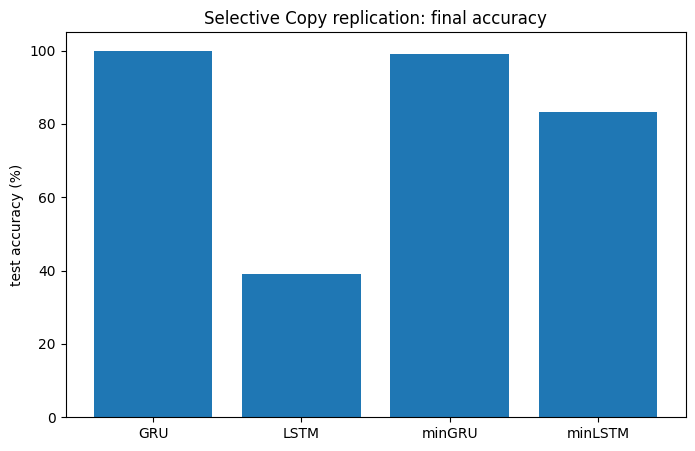

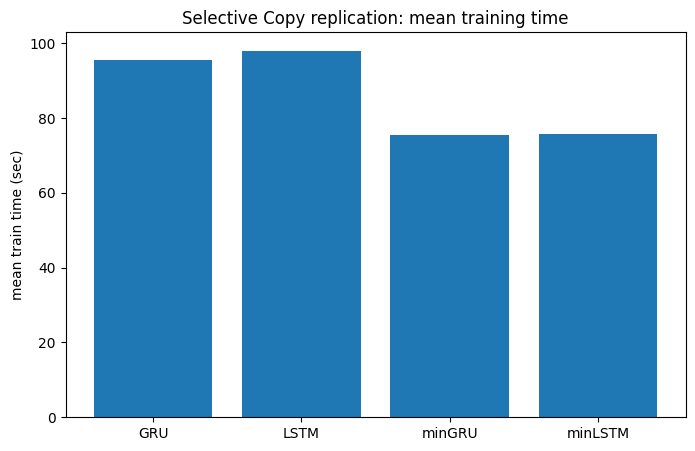

In [18]:
plot_df = summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], 100 * plot_df["test_acc_mean"])
plt.ylabel("test accuracy (%)")
plt.title("Selective Copy replication: final accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["train_time_mean_sec"])
plt.ylabel("mean train time (sec)")
plt.title("Selective Copy replication: mean training time")
plt.show()

# Extension: Generalization to longer sequences

In [19]:
# pick the best seed per model
best_model_objects = {}
for model_name in MODELS:
    subset = [r for r in all_results if r["model_name"] == model_name]
    best_r = max(subset, key=lambda x: x["test_acc"])
    best_model_objects[model_name] = best_r["model"]

lengths = [CFG.sequence_length, CFG.sequence_length * 2, CFG.sequence_length * 4]
generalization_rows = []

for model_name, model in best_model_objects.items():
    for L in lengths:
        metrics = evaluate_model(model, CFG, seed=1, num_batches=50, sequence_length=L)
        generalization_rows.append({
            "model": model_name,
            "sequence_length": L,
            "test_acc": metrics["acc"],
            "test_loss": metrics["loss"],
        })

generalization_df = pd.DataFrame(generalization_rows)
generalization_df

,model,sequence_length,test_acc,test_loss
0,minGRU,256,0.995820,0.013647
1,minGRU,512,0.995234,0.015485
2,minGRU,1024,0.988672,0.036008
3,minLSTM,256,0.858398,0.378242
4,minLSTM,512,0.116836,4.182425
5,minLSTM,1024,0.067656,5.784634
6,GRU,256,0.999922,0.000568
7,GRU,512,0.999609,0.001358
8,GRU,1024,0.921758,0.379714
9,LSTM,256,0.404727,1.546361


# Plot length generalization

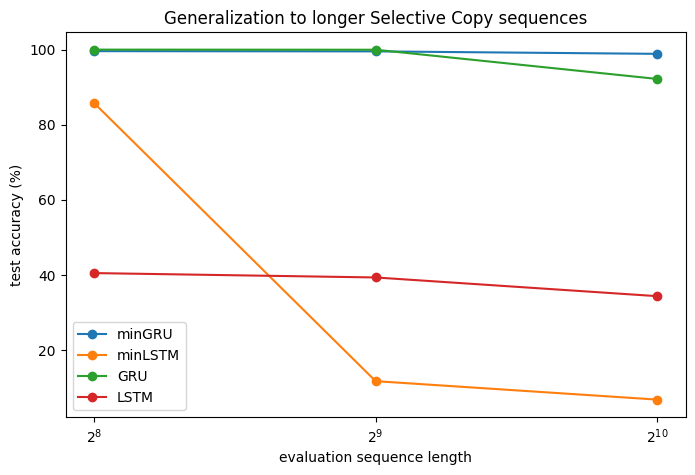

In [20]:
plt.figure(figsize=(8, 5))
for model_name in generalization_df["model"].unique():
    sub = generalization_df[generalization_df["model"] == model_name]
    plt.plot(sub["sequence_length"], 100 * sub["test_acc"], marker="o", label=model_name)

plt.xlabel("evaluation sequence length")
plt.ylabel("test accuracy (%)")
plt.title("Generalization to longer Selective Copy sequences")
plt.legend()
plt.xscale("log", base=2)
plt.show()

# Compare with original work's reported numbers

In [22]:
""" paper_df = pd.DataFrame([
    {"model": "minGRU", "paper_selective_copy_acc_mean": 99.5, "paper_selective_copy_acc_std": 0.2},
    {"model": "minLSTM", "paper_selective_copy_acc_mean": 96.0, "paper_selective_copy_acc_std": 2.8},
])

compare_df = summary_df.merge(paper_df, on="model", how="left")
compare_df["ours_acc_mean_pct"] = 100 * compare_df["test_acc_mean"]
compare_df["support_gap_pct_points"] = compare_df["ours_acc_mean_pct"] - compare_df["paper_selective_copy_acc_mean"]

compare_df[[
    "model",
    "params",
    "ours_acc_mean_pct",
    "paper_selective_copy_acc_mean",
    "paper_selective_copy_acc_std",
    "support_gap_pct_points",
]] """

' paper_df = pd.DataFrame([\n    {"model": "minGRU", "paper_selective_copy_acc_mean": 99.5, "paper_selective_copy_acc_std": 0.2},\n    {"model": "minLSTM", "paper_selective_copy_acc_mean": 96.0, "paper_selective_copy_acc_std": 2.8},\n])\n\ncompare_df = summary_df.merge(paper_df, on="model", how="left")\ncompare_df["ours_acc_mean_pct"] = 100 * compare_df["test_acc_mean"]\ncompare_df["support_gap_pct_points"] = compare_df["ours_acc_mean_pct"] - compare_df["paper_selective_copy_acc_mean"]\n\ncompare_df[[\n    "model",\n    "params",\n    "ours_acc_mean_pct",\n    "paper_selective_copy_acc_mean",\n    "paper_selective_copy_acc_std",\n    "support_gap_pct_points",\n]] '